Companion notebook for *A Probabilistic Mixture Model for Evaluating Sound Localisation Performance in the Median Plane* (Sztandera, Picinali, Barumerli, Forum Acusticum 2026). Run it from the repository root; it reads `data/AXD_measured.csv` (see `data/README.md`).

# Saturation Analysis

Demonstrates that `rmsPmedianlocal` saturates at high polar scatter while `sigma_mix` from the mixture model does not.

- **Figure 1** — Rank comparison: does `sigma_mix` re-rank participants relative to `rmsPlocal`?
- **Figure 2** — Simulated saturation curve with real AXD participants overlaid.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import joblib

from metrics import rmsPmedianlocal, wrap_polar_angle
from bayesian_metric import sigma_to_kappa, polar_mirror, fit_mixture_querr

## Load data and compute metrics

In [2]:
obs_tbl      = pd.read_csv('data/AXD_measured.csv')   # Measured condition only
obs_tbl      = obs_tbl[obs_tbl['participant'] != 'P0247'].reset_index(drop=True)
participants = sorted(obs_tbl['participant'].unique())

central_rows = obs_tbl[
    np.abs(obs_tbl['lat_target']) <= 30.0
][['lat_target', 'pol_target']].reset_index(drop=True)

def _compute_participant(pid):
    df      = obs_tbl[obs_tbl['participant'] == pid]
    true_hp = np.column_stack([np.deg2rad(df['lat_target'].values),
                                np.deg2rad(df['pol_target'].values)])
    est_hp  = np.column_stack([np.deg2rad(df['lat_response'].values),
                                np.deg2rad(df['pol_response'].values)])
    mix = fit_mixture_querr(df)
    return {
        'participant':   pid,
        'n_trials':      len(df),
        'rmsPlocal_deg': np.rad2deg(rmsPmedianlocal(true_hp, est_hp)[0]),
        'sigma_mix_deg': mix['sigma_hat'],
        'w_hat':         mix['w_hat'],
    }

rows       = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(_compute_participant)(pid) for pid in participants
)
metrics_df = pd.DataFrame(rows).set_index('participant')
metrics_df

,n_trials,rmsPlocal_deg,sigma_mix_deg,w_hat
participant,,,,
P0001,297,34.490431,42.534888,0.968379
P0003,99,30.534063,40.392843,0.999950
P0005,99,42.774476,48.590399,0.758294
P0006,297,37.029608,47.161498,0.949069
P0015,198,36.493469,36.991946,0.944934
P0019,198,27.313616,29.344739,0.832208
P0020,99,28.680280,41.081321,0.893572
P0031,198,36.821460,33.647313,0.903321
P0043,99,20.800662,19.948812,0.868749


In [3]:
# Classical querr: fraction of central trials where |polar_error| >= 90°
def _querr_classical(pid):
    df      = obs_tbl[obs_tbl['participant'] == pid]
    central = df[np.abs(df['lat_target']) <= 30.0]
    pol_err = wrap_polar_angle(
        np.deg2rad(central['pol_response'].values) -
        np.deg2rad(central['pol_target'].values)
    )
    return 100.0 * np.mean(np.abs(pol_err) >= np.pi / 2)

metrics_df['querr_classical'] = [_querr_classical(pid) for pid in metrics_df.index]
metrics_df['confusion_pct']   = (1 - metrics_df['w_hat']) * 100

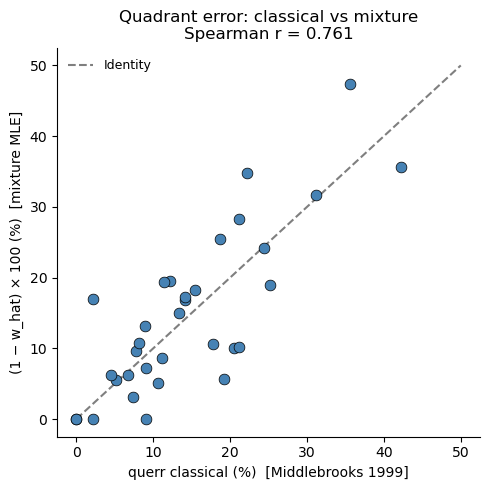

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))

x = metrics_df['querr_classical']
y = metrics_df['confusion_pct']

r, _ = spearmanr(x, y)
ax.scatter(x, y, s=60, color='steelblue', edgecolors='black', linewidths=0.5, zorder=3)
ax.plot([0, 50], [0, 50], 'k--', lw=1.5, alpha=0.5, label='Identity')

ax.set_xlabel('querr classical (%)  [Middlebrooks 1999]')
ax.set_ylabel('(1 − w_hat) × 100 (%)  [mixture MLE]')
ax.set_title(f'Quadrant error: classical vs mixture\nSpearman r = {r:.3f}')
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Saturation curve

Simulation sweep: `w` fixed at the sample mean, `sigma_true` varied from 5° to 80°. At each level, 300 synthetic datasets (N=45 central trials each) are generated and `rmsPmedianlocal` is computed. The blue curve shows the expected `rmsPlocal` as a function of `sigma_true` — it flattens well before 45°. Real AXD participants are overlaid using their `(sigma_mix, rmsPlocal)` values.

In [5]:
W_FIX    = float(metrics_df['w_hat'].mean())
N_TRIALS = 45
N_REP    = 300

sigma_grid = np.arange(5, 82, 5, dtype=float)
rng_master = np.random.default_rng(0)
sim_seeds  = rng_master.integers(0, 2**31, len(sigma_grid))

_central_rows = central_rows  # explicit capture for joblib

def _sim_rmsP(sigma_true, w, n_trials, n_rep, c_rows, seed):
    rng   = np.random.default_rng(seed)
    kappa = sigma_to_kappa(sigma_true)
    vals  = []
    for _ in range(n_rep):
        idx     = rng.choice(len(c_rows), size=n_trials, replace=True)
        lat_t   = np.deg2rad(c_rows.iloc[idx]['lat_target'].values)
        pol_t   = wrap_polar_angle(np.deg2rad(c_rows.iloc[idx]['pol_target'].values))
        mu      = np.where(rng.random(n_trials) < w, pol_t, polar_mirror(pol_t))
        pol_r   = wrap_polar_angle(rng.vonmises(mu, kappa))
        true_hp = np.column_stack([lat_t, pol_t])
        est_hp  = np.column_stack([lat_t, pol_r])
        try:
            vals.append(np.rad2deg(rmsPmedianlocal(true_hp, est_hp)[0]))
        except ValueError:
            vals.append(np.nan)
    arr = np.array(vals)
    return np.nanmean(arr), np.nanstd(arr)

sim_out   = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(_sim_rmsP)(s, W_FIX, N_TRIALS, N_REP, _central_rows, sim_seeds[i])
    for i, s in enumerate(sigma_grid)
)
rmsP_mean = np.array([r[0] for r in sim_out])
rmsP_std  = np.array([r[1] for r in sim_out])

## Simulation: rmsPlocal saturation vs sigma_hat recovery (text summary)

Sweep `sigma_true` from 10° to 70°, fixing `w` at the sample mean and N=45 central trials.
For each level, generate `N_REP_FIT=30` synthetic participants, compute both metrics, and print a comparison table.
A positive `bias_rms` means rmsPlocal *underestimates* true scatter; a near-zero `bias_sig` means sigma_hat tracks correctly.

In [6]:
N_REP_FIT         = 60
sigma_grid_coarse = np.arange(10, 85, 10, dtype=float)   # 10, 20, …, 70
sim_seeds2        = np.random.default_rng(42).integers(0, 2**31, len(sigma_grid_coarse))

def _sim_both(sigma_true, w, n_trials, n_rep, c_rows, seed):
    print(sigma_true)
    rng   = np.random.default_rng(seed)
    kappa = sigma_to_kappa(sigma_true)
    rms_vals, sig_vals = [], []
    for _ in range(n_rep):
        idx   = rng.choice(len(c_rows), size=n_trials, replace=True)
        lat_t = c_rows.iloc[idx]['lat_target'].values          # degrees
        pol_t = wrap_polar_angle(np.deg2rad(c_rows.iloc[idx]['pol_target'].values))
        mu    = np.where(rng.random(n_trials) < w, pol_t, polar_mirror(pol_t))
        pol_r = wrap_polar_angle(rng.vonmises(mu, kappa))

        # rmsPmedianlocal
        true_hp = np.column_stack([np.deg2rad(lat_t), pol_t])
        est_hp  = np.column_stack([np.deg2rad(lat_t), pol_r])
        try:
            rms_vals.append(np.rad2deg(rmsPmedianlocal(true_hp, est_hp)[0]))
        except ValueError:
            rms_vals.append(np.nan)

        # sigma_hat via mixture MLE
        df_syn = pd.DataFrame({
            'lat_target':   lat_t,
            'pol_target':   np.rad2deg(pol_t),
            'pol_response': np.rad2deg(pol_r),
        })
        mix = fit_mixture_querr(df_syn)
        sig_vals.append(mix['sigma_hat'])

    return (np.nanmean(rms_vals), np.nanstd(rms_vals),
            np.nanmean(sig_vals), np.nanstd(sig_vals))

sim_both_out = joblib.Parallel(n_jobs=-1)(
    joblib.delayed(_sim_both)(s, W_FIX, N_TRIALS, N_REP_FIT, central_rows, sim_seeds2[i])
    for i, s in enumerate(sigma_grid_coarse)
)

rmsP_r_mean = np.array([r[0] for r in sim_both_out])
rmsP_r_std  = np.array([r[1] for r in sim_both_out])
sigH_r_mean = np.array([r[2] for r in sim_both_out])
sigH_r_std  = np.array([r[3] for r in sim_both_out])

# ── Text summary ──────────────────────────────────────────────────────────────
header = f"{'sigma_true':>12} | {'E[rmsPlocal]':>13} | {'E[sigma_hat]':>13} | {'bias_rms':>10} | {'bias_sig':>10}"
print(header)
print("-" * len(header))
for i, s in enumerate(sigma_grid_coarse):
    print(f"{s:12.1f} | {rmsP_r_mean[i]:13.2f} | {sigH_r_mean[i]:13.2f} | "
          f"{rmsP_r_mean[i]-s:10.2f} | {sigH_r_mean[i]-s:10.2f}")

  sigma_true |  E[rmsPlocal] |  E[sigma_hat] |   bias_rms |   bias_sig
----------------------------------------------------------------------
        10.0 |         13.35 |          9.86 |       3.35 |      -0.14
        20.0 |         22.19 |         19.78 |       2.19 |      -0.22
        30.0 |         29.46 |         28.64 |      -0.54 |      -1.36
        40.0 |         36.44 |         39.67 |      -3.56 |      -0.33
        50.0 |         41.02 |         52.39 |      -8.98 |       2.39
        60.0 |         42.86 |         60.39 |     -17.14 |       0.39
        70.0 |         45.57 |         69.61 |     -24.43 |      -0.39
        80.0 |         47.27 |         74.84 |     -32.73 |      -5.16


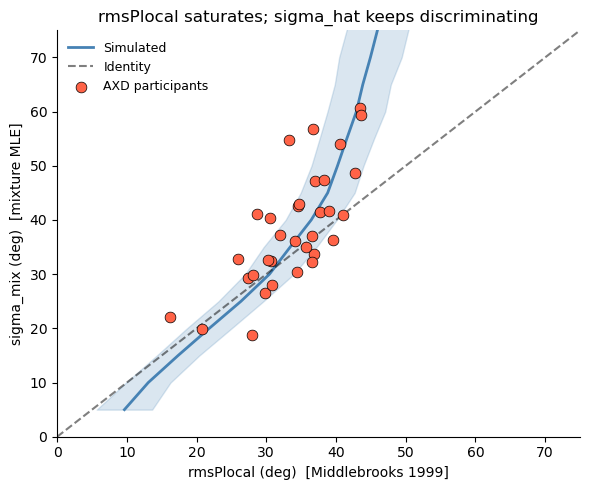

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

# Blue: E[rmsPlocal] → sigma_true (fine grid). Goes vertical as rmsPlocal saturates.
ax.fill_betweenx(sigma_grid,
                 rmsP_mean - rmsP_std,
                 rmsP_mean + rmsP_std,
                 alpha=0.2, color='steelblue')
ax.plot(rmsP_mean, sigma_grid, '-', color='steelblue', lw=2,
        label=f'Simulated')

# Identity
ax.plot([0, 75], [0, 75], 'k--', lw=1.5, alpha=0.5, label='Identity')

# Real AXD participants
ax.scatter(metrics_df['rmsPlocal_deg'], metrics_df['sigma_mix_deg'],
           s=60, color='tomato', edgecolors='black', linewidths=0.5,
           zorder=5, label='AXD participants')

ax.set_xlim(0, 75)
ax.set_ylim(0, 75)
ax.set_xlabel('rmsPlocal (deg)  [Middlebrooks 1999]')
ax.set_ylabel('sigma_mix (deg)  [mixture MLE]')
ax.set_title('rmsPlocal saturates; sigma_hat keeps discriminating')
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()